# Rating Attribution Analysis — Week 7

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# load the features computed in week 6
df = pd.read_parquet("week6_features_full.parquet")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nHead:")
print(df.head(3))

Shape: (6499635, 9)

Columns: ['noteId', 'ratedOnTweetId', 'raterParticipantId', 'ratingCreatedAt', 'fromNotification', 'is_rating_session', 'is_same_post_interest', 'is_notification', 'is_rater_swarm']

Head:
                noteId       ratedOnTweetId  \
0  2016534713742061788  2016246745739546987   
1  2017641230612451495  2017578816177111423   
2  2018404224149717157  2018387895459983768   

                                  raterParticipantId         ratingCreatedAt  \
0  00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40... 2026-01-28 20:47:22.321   
1  00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40... 2026-01-31 17:21:23.365   
2  00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40... 2026-02-02 22:44:01.605   

   fromNotification  is_rating_session  is_same_post_interest  \
0             False              False                  False   
1             False              False                  False   
2             False              False                  False   

   is_notification 

## Q1: Do the rating attributions accurately capture the behavior?

In [6]:
# proportion of ratings attributed to each pathway
flags = ["is_rating_session", "is_same_post_interest", "is_notification", "is_rater_swarm"]

print("--- proportion of ratings per pathway ---")
for f in flags:
    cnt = df[f].sum()
    pct = df[f].mean() * 100
    print(f"  {f}: {cnt:,} ({pct:.2f}%)")

# how many ratings have NO pathway at all?
df["no_pathway"] = ~df[flags].any(axis=1)
print(f"\n  no pathway: {df['no_pathway'].sum():,} ({df['no_pathway'].mean()*100:.2f}%)")

--- proportion of ratings per pathway ---
  is_rating_session: 3,837,599 (59.04%)
  is_same_post_interest: 3,309,659 (50.92%)
  is_notification: 128,736 (1.98%)
  is_rater_swarm: 8,199 (0.13%)

  no pathway: 2,497,380 (38.42%)


In [7]:
# check for conflicting combinations

# 1) session-end ratings that also come from notification or swarm
# "session end" = in a session, but the NEXT rating is >5min away (or no next rating)
df_sorted = df.sort_values(["raterParticipantId", "ratingCreatedAt"])
gap_next = df_sorted.groupby("raterParticipantId")["ratingCreatedAt"].diff(-1).abs()
session_gap = pd.Timedelta(minutes=5)
is_session_end = df_sorted["is_rating_session"] & ((gap_next > session_gap) | gap_next.isna())

session_end_and_notif = (is_session_end & df_sorted["is_notification"]).sum()
session_end_and_swarm = (is_session_end & df_sorted["is_rater_swarm"]).sum()
print("--- conflict check: session-end overlap ---")
print(f"  session end + notification: {session_end_and_notif:,}")
print(f"  session end + swarm: {session_end_and_swarm:,}")

# 2) swarm ratings that also come from notification or session
swarm_and_notif = (df["is_rater_swarm"] & df["is_notification"]).sum()
swarm_and_session = (df["is_rater_swarm"] & df["is_rating_session"]).sum()
print("\n--- conflict check: swarm overlap ---")
print(f"  swarm + notification: {swarm_and_notif:,}")
print(f"  swarm + session: {swarm_and_session:,}")

--- conflict check: session-end overlap ---
  session end + notification: 9,033
  session end + swarm: 1,123

--- conflict check: swarm overlap ---
  swarm + notification: 61
  swarm + session: 3,592


### Threshold sensitivity analysis

In [8]:
# test different thresholds for session gap and swarm parameters

# --- session gap sensitivity ---
print("--- session gap sensitivity ---")
df_sorted = df.sort_values(["raterParticipantId", "ratingCreatedAt"])
gap_prev = df_sorted.groupby("raterParticipantId")["ratingCreatedAt"].diff()
gap_next = df_sorted.groupby("raterParticipantId")["ratingCreatedAt"].diff(-1).abs()

for minutes in [2, 3, 5, 10, 15]:
    threshold = pd.Timedelta(minutes=minutes)
    in_session = (gap_prev <= threshold) | (gap_next <= threshold)
    pct = in_session.mean() * 100
    print(f"  {minutes} min: {pct:.2f}%")

# --- swarm threshold sensitivity ---
print("\n--- swarm min ratings sensitivity ---")
note_stats = df.groupby("noteId")["ratingCreatedAt"].agg(
    rating_count="count",
    first_rating="min",
    last_rating="max",
)
note_stats["span"] = note_stats["last_rating"] - note_stats["first_rating"]

for min_count in [10, 15, 20, 30, 50]:
    is_swarm = (
        (note_stats["rating_count"] >= min_count)
        & (note_stats["span"] <= pd.Timedelta(hours=1))
    )
    swarm_notes = is_swarm.sum()
    swarm_ratings = df[df["noteId"].isin(note_stats[is_swarm].index)].shape[0]
    pct = swarm_ratings / len(df) * 100
    print(f"  min {min_count} ratings: {swarm_notes} notes, {swarm_ratings:,} ratings ({pct:.2f}%)")

# --- swarm window sensitivity ---
print("\n--- swarm window sensitivity ---")
for hours in [0.5, 1, 2, 4]:
    is_swarm = (
        (note_stats["rating_count"] >= 20)
        & (note_stats["span"] <= pd.Timedelta(hours=hours))
    )
    swarm_notes = is_swarm.sum()
    swarm_ratings = df[df["noteId"].isin(note_stats[is_swarm].index)].shape[0]
    pct = swarm_ratings / len(df) * 100
    print(f"  {hours}h window: {swarm_notes} notes, {swarm_ratings:,} ratings ({pct:.2f}%)")

--- session gap sensitivity ---
  2 min: 55.89%
  3 min: 57.29%
  5 min: 59.04%
  10 min: 61.44%
  15 min: 62.83%

--- swarm min ratings sensitivity ---
  min 10 ratings: 441 notes, 11,732 ratings (0.18%)
  min 15 ratings: 247 notes, 9,500 ratings (0.15%)
  min 20 ratings: 168 notes, 8,199 ratings (0.13%)
  min 30 ratings: 98 notes, 6,527 ratings (0.10%)
  min 50 ratings: 43 notes, 4,496 ratings (0.07%)

--- swarm window sensitivity ---
  0.5h window: 56 notes, 2,361 ratings (0.04%)
  1h window: 168 notes, 8,199 ratings (0.13%)
  2h window: 469 notes, 23,403 ratings (0.36%)
  4h window: 1098 notes, 59,375 ratings (0.91%)


## Q2: To what extent are ratings created using each pathway?

In [10]:
# load helpfulnessLevel from original dataset for note status breakdown
df_extra = pd.read_parquet(
    "../../../dataset 2.24/ratings-20260117-20260217.parquet",
    columns=["noteId", "raterParticipantId", "ratingCreatedAt", "helpfulnessLevel"]
)

# merge into df
df = df.merge(
    df_extra[["noteId", "raterParticipantId", "ratingCreatedAt", "helpfulnessLevel"]],
    on=["noteId", "raterParticipantId", "ratingCreatedAt"],
    how="left",
)
print("helpfulnessLevel value counts:")
print(df["helpfulnessLevel"].value_counts(dropna=False))

helpfulnessLevel value counts:
helpfulnessLevel
HELPFUL             4039769
NOT_HELPFUL         2336133
SOMEWHAT_HELPFUL     123733
Name: count, dtype: int64


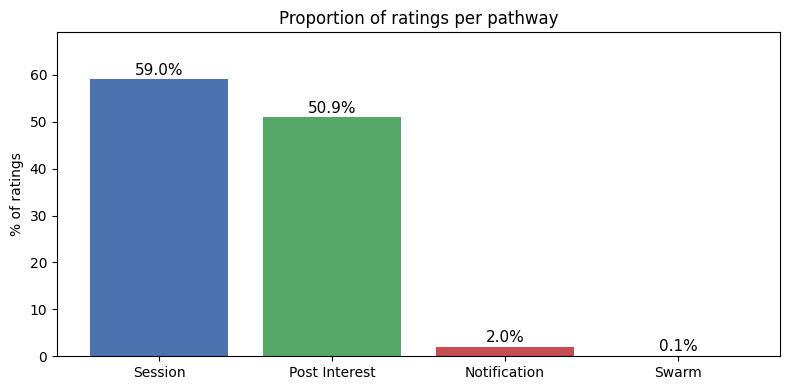

In [11]:
flags = ["is_rating_session", "is_same_post_interest", "is_notification", "is_rater_swarm"]
labels = ["Session", "Post Interest", "Notification", "Swarm"]

# overall proportion bar chart
pcts = [df[f].mean() * 100 for f in flags]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, pcts, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
for bar, p in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{p:.1f}%", ha="center", fontsize=11)
ax.set_ylabel("% of ratings")
ax.set_title("Proportion of ratings per pathway")
ax.set_ylim(0, max(pcts) + 10)
plt.tight_layout()
plt.show()

                  Session  Post Interest  Notification  Swarm
helpfulnessLevel                                             
HELPFUL             54.74          45.34          2.56   0.11
NOT_HELPFUL         66.38          60.53          0.80   0.15
SOMEWHAT_HELPFUL    60.92          51.60          5.16   0.10


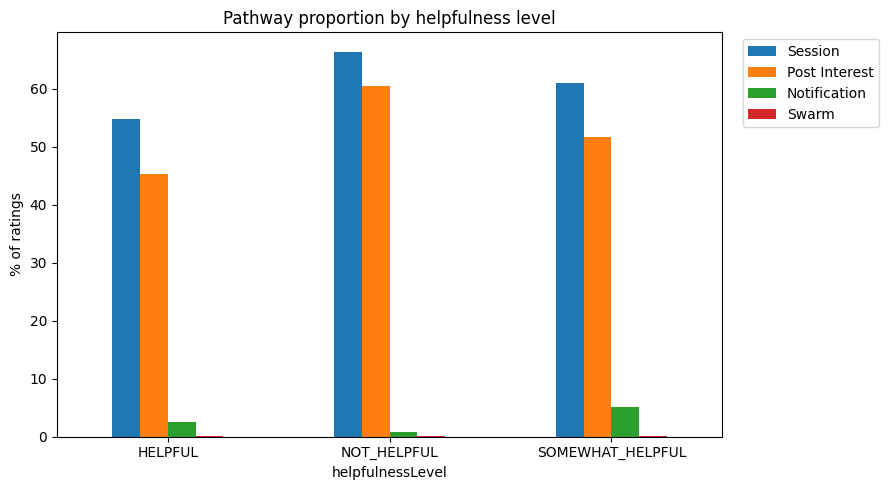

In [12]:
# pathway breakdown by note helpfulness level
breakdown = df.groupby("helpfulnessLevel")[flags].mean() * 100
breakdown.columns = labels
print(breakdown.round(2))

# grouped bar chart
breakdown.plot(kind="bar", figsize=(9, 5), rot=0)
plt.ylabel("% of ratings")
plt.title("Pathway proportion by helpfulness level")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

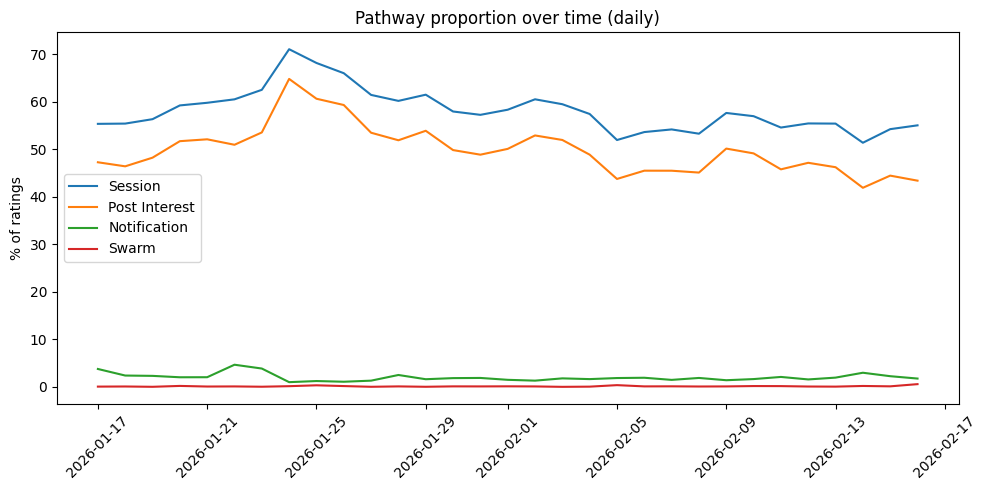

In [13]:
# pathway proportion over time (daily)
df["date"] = df["ratingCreatedAt"].dt.date

daily = df.groupby("date")[flags].mean() * 100
daily.columns = labels

fig, ax = plt.subplots(figsize=(10, 5))
for col in daily.columns:
    ax.plot(daily.index, daily[col], label=col, linewidth=1.5)
ax.set_ylabel("% of ratings")
ax.set_title("Pathway proportion over time (daily)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Q3: To what extent do individual users tend to rate using different pathways?

In [14]:
flags = ["is_rating_session", "is_same_post_interest", "is_notification", "is_rater_swarm"]

# per-user pathway proportions
user_stats = df.groupby("raterParticipantId").agg(
    total_ratings=("noteId", "size"),
    pct_session=("is_rating_session", "mean"),
    pct_post_interest=("is_same_post_interest", "mean"),
    pct_notification=("is_notification", "mean"),
    pct_swarm=("is_rater_swarm", "mean"),
)
user_stats[["pct_session", "pct_post_interest", "pct_notification", "pct_swarm"]] *= 100

print(f"Total users: {len(user_stats):,}")
print("\nUser-level pathway % distribution:")
print(user_stats[["pct_session", "pct_post_interest", "pct_notification", "pct_swarm"]].describe().round(2))

Total users: 484,059

User-level pathway % distribution:
       pct_session  pct_post_interest  pct_notification  pct_swarm
count    484059.00          484059.00         484059.00  484059.00
mean         30.85              27.38              3.58       0.17
std          35.24              33.52             15.24       2.94
min           0.00               0.00              0.00       0.00
25%           0.00               0.00              0.00       0.00
50%          11.76               0.00              0.00       0.00
75%          62.50              54.17              0.00       0.00
max         100.00             100.00            100.00     100.00


--- users with a single dominant pathway (>50%) ---
  161,226 / 484,059 (33.3%)

--- dominant pathway breakdown ---
dominant
Session          451688
Notification      19808
Post Interest     11598
Swarm               965
Name: count, dtype: int64


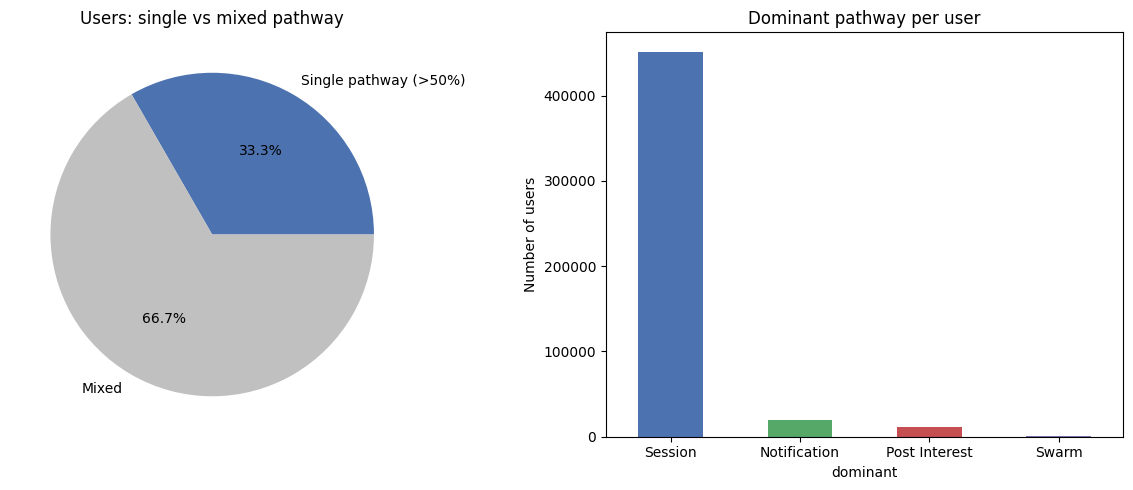

In [15]:
# classify each user's "dominant pathway"
# dominant = the pathway with highest proportion of their ratings
pathway_cols = ["pct_session", "pct_post_interest", "pct_notification", "pct_swarm"]
pathway_labels = ["Session", "Post Interest", "Notification", "Swarm"]

user_stats["dominant"] = user_stats[pathway_cols].idxmax(axis=1).map(
    dict(zip(pathway_cols, pathway_labels))
)

# how many users have >50% of their ratings from a single pathway?
user_stats["max_pct"] = user_stats[pathway_cols].max(axis=1)
user_stats["single_pathway"] = user_stats["max_pct"] > 50

print("--- users with a single dominant pathway (>50%) ---")
print(f"  {user_stats['single_pathway'].sum():,} / {len(user_stats):,} "
      f"({user_stats['single_pathway'].mean()*100:.1f}%)")

print("\n--- dominant pathway breakdown ---")
print(user_stats["dominant"].value_counts())

# visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# pie chart: single vs multi pathway users
axes[0].pie(
    [user_stats["single_pathway"].sum(), (~user_stats["single_pathway"]).sum()],
    labels=["Single pathway (>50%)", "Mixed"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#C0C0C0"],
)
axes[0].set_title("Users: single vs mixed pathway")

# dominant pathway distribution
user_stats["dominant"].value_counts().plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
)
axes[1].set_title("Dominant pathway per user")
axes[1].set_ylabel("Number of users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

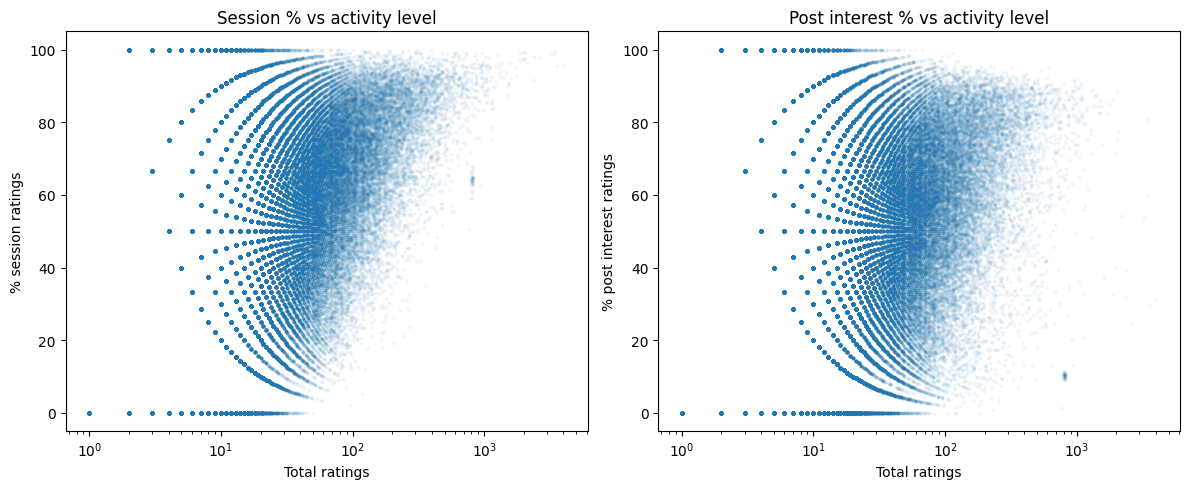

In [16]:
# does pathway mix relate to how active a user is?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# session % vs total ratings
axes[0].scatter(user_stats["total_ratings"], user_stats["pct_session"],
                alpha=0.05, s=3)
axes[0].set_xlabel("Total ratings")
axes[0].set_ylabel("% session ratings")
axes[0].set_title("Session % vs activity level")
axes[0].set_xscale("log")

# post interest % vs total ratings
axes[1].scatter(user_stats["total_ratings"], user_stats["pct_post_interest"],
                alpha=0.05, s=3)
axes[1].set_xlabel("Total ratings")
axes[1].set_ylabel("% post interest ratings")
axes[1].set_title("Post interest % vs activity level")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()